<a id = "1"></a><br>
# Load Python Pakages


In [1]:
#basics
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


#preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer


#statistics
from scipy import stats
from scipy.stats import skew
from scipy.special import boxcox1p


#feature engineering
from sklearn.feature_selection import mutual_info_classif


#transformers and pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import set_config




#model evaluation
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_validate
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, log_loss


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:

! ls ../input/flaml12/flaml

FLAML-1.2.3-py3-none-any.whl
joblib-1.2.0-py3-none-any.whl
lightgbm-3.3.5-py3-none-manylinux1_x86_64.whl
numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
pandas-2.0.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
python_dateutil-2.8.2-py2.py3-none-any.whl
pytz-2023.3-py2.py3-none-any.whl
scikit_learn-1.2.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
scipy-1.10.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
six-1.16.0-py2.py3-none-any.whl
threadpoolctl-3.1.0-py3-none-any.whl
tzdata-2023.3-py2.py3-none-any.whl
wheel-0.40.0-py3-none-any.whl
xgboost-1.7.5-py3-none-manylinux2014_x86_64.whl


In [3]:
#installing flaml ofline 
!pip install flaml --no-index --find-links=file:///kaggle/input/flaml12/flaml

Looking in links: file:///kaggle/input/flaml12/flaml
Processing /kaggle/input/flaml12/flaml/FLAML-1.2.3-py3-none-any.whl


<a id = "2"></a><br>
#  First look to data

In [4]:
# Read the data
train = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv').drop(['Id'], axis=1)
test = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/test.csv').drop(['Id'], axis=1)
greeks = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/greeks.csv').drop(['Id'], axis=1)

# reserved for pipeline
pipe_data = train.copy()
pipe_test = test.copy()


# use for preliminary analysis
train_df = train.copy()
test_df = test.copy()
train_df.head()

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,4126.58731,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,5496.92824,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,5135.78024,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,4169.67738,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,5728.73412,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


In [5]:
test_df.head()

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


All zeros?

In [6]:
# is there any missing value?
train_df.isnull().any().any()

True

In [7]:
missing = pd.DataFrame(train_df.isnull().sum().sort_values(ascending=False))
missing.columns = ["count"]
missing = missing.loc[(missing!=0).any(axis=1)]
missing["percent"] = missing[0:] / 1460
missing.style.background_gradient('viridis')

,count,percent
EL,60,0.041096
BQ,60,0.041096
CC,3,0.002055
CB,2,0.001370
FS,2,0.001370
FL,1,0.000685
FC,1,0.000685
DU,1,0.000685
GL,1,0.000685


## Descpriptive statistics

In [8]:
#numerical feature descriptive statistics
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AB,617.0,0.477149,0.468388,0.081187,0.252107,0.354659,0.559763,6.161666
AF,617.0,3502.013221,2300.322717,192.593280,2197.345480,3120.318960,4361.637390,28688.187660
AH,617.0,118.624513,127.838950,85.200147,85.200147,85.200147,113.739540,1910.123198
AM,617.0,38.968552,69.728226,3.177522,12.270314,20.533110,39.139886,630.518230
AR,617.0,10.128242,10.518877,8.138688,8.138688,8.138688,8.138688,178.943634
AX,617.0,5.545576,2.551696,0.699861,4.128294,5.031912,6.431634,38.270880
AY,617.0,0.060320,0.416817,0.025578,0.025578,0.025578,0.036845,10.315851
AZ,617.0,10.566447,4.350645,3.396778,8.129580,10.461320,12.969516,38.971568
BC,617.0,8.053012,65.166943,1.229900,1.229900,1.229900,5.081244,1463.693448
BD,617.0,5350.388655,3021.326641,1693.624320,4155.702870,4997.960730,6035.885700,53060.599240


## Grouping features for preprocessing purposes

In [9]:
# Just bookkeeping
feature_list = [feature for feature in train_df.columns if not feature  == "Class"]

categorical_features= ['EJ']
continuous_features = list(set(feature_list) - set(categorical_features))
assert feature_list.sort() == (continuous_features + categorical_features).sort()

<a id = "3"></a><br>
# Exploratory Data Analysis

Let's obsorve how target variable changes with features.

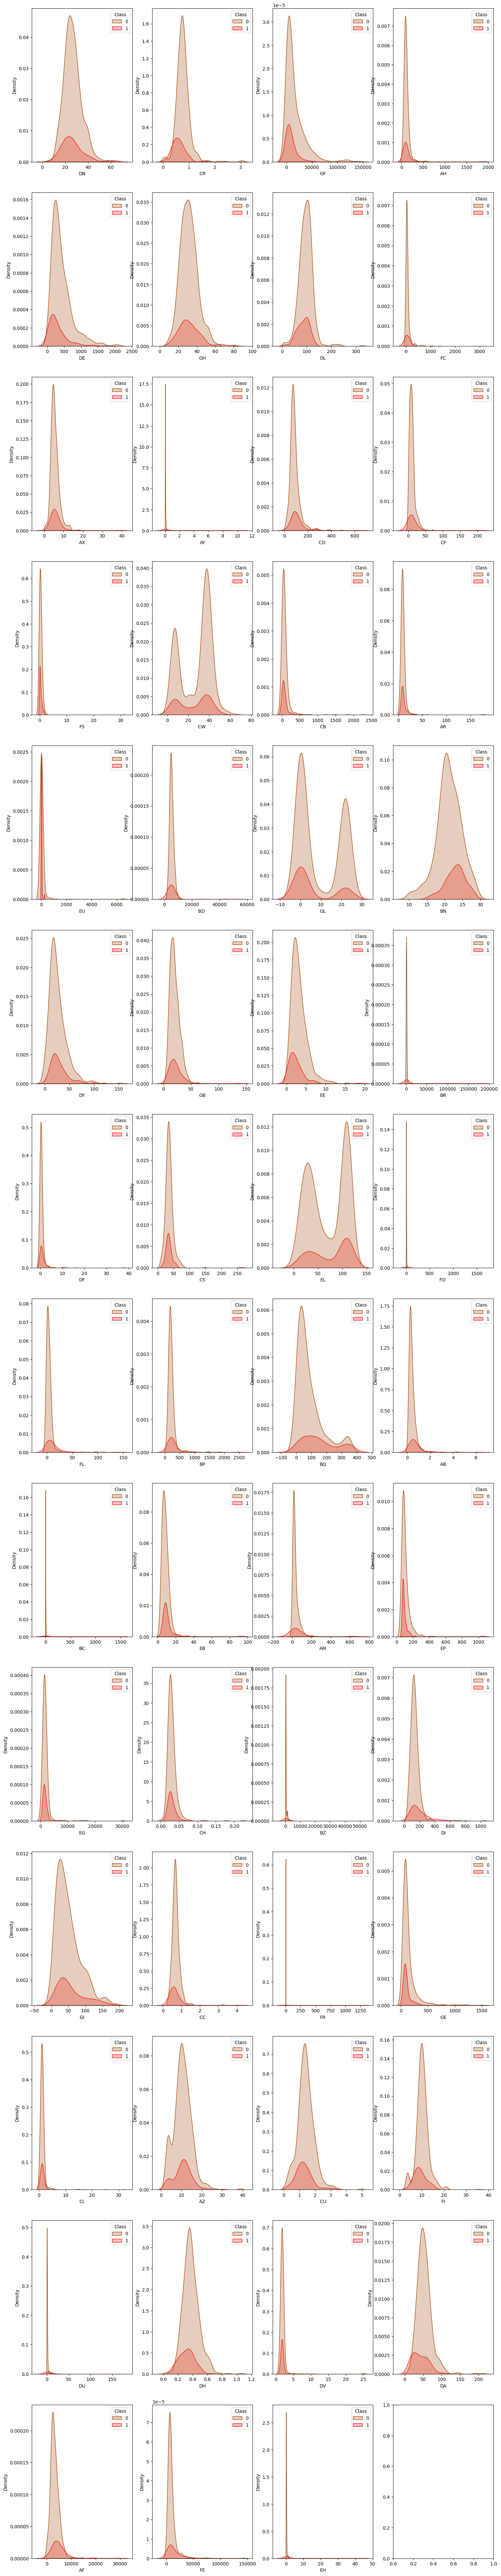

In [10]:
fig, ax = plt.subplots(14, 4, figsize=(18, 100))
for var, subplot in zip(continuous_features, ax.flatten()):
    sns.kdeplot(x= var, data=train_df, ax=subplot, palette=['#9E3F00', 'red'], hue = 'Class', fill=True)

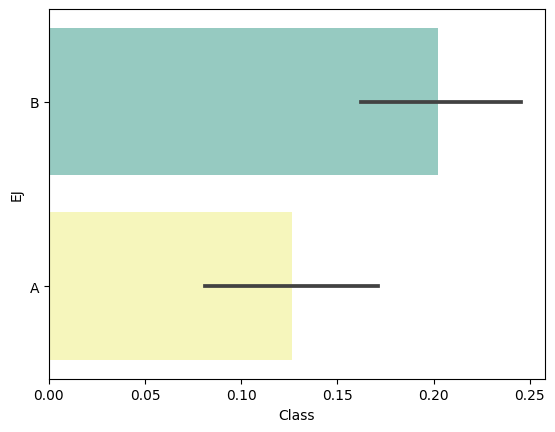

In [11]:
sns.barplot(x='Class', y= 'EJ', data=train_df, palette='Set3')
plt.show()

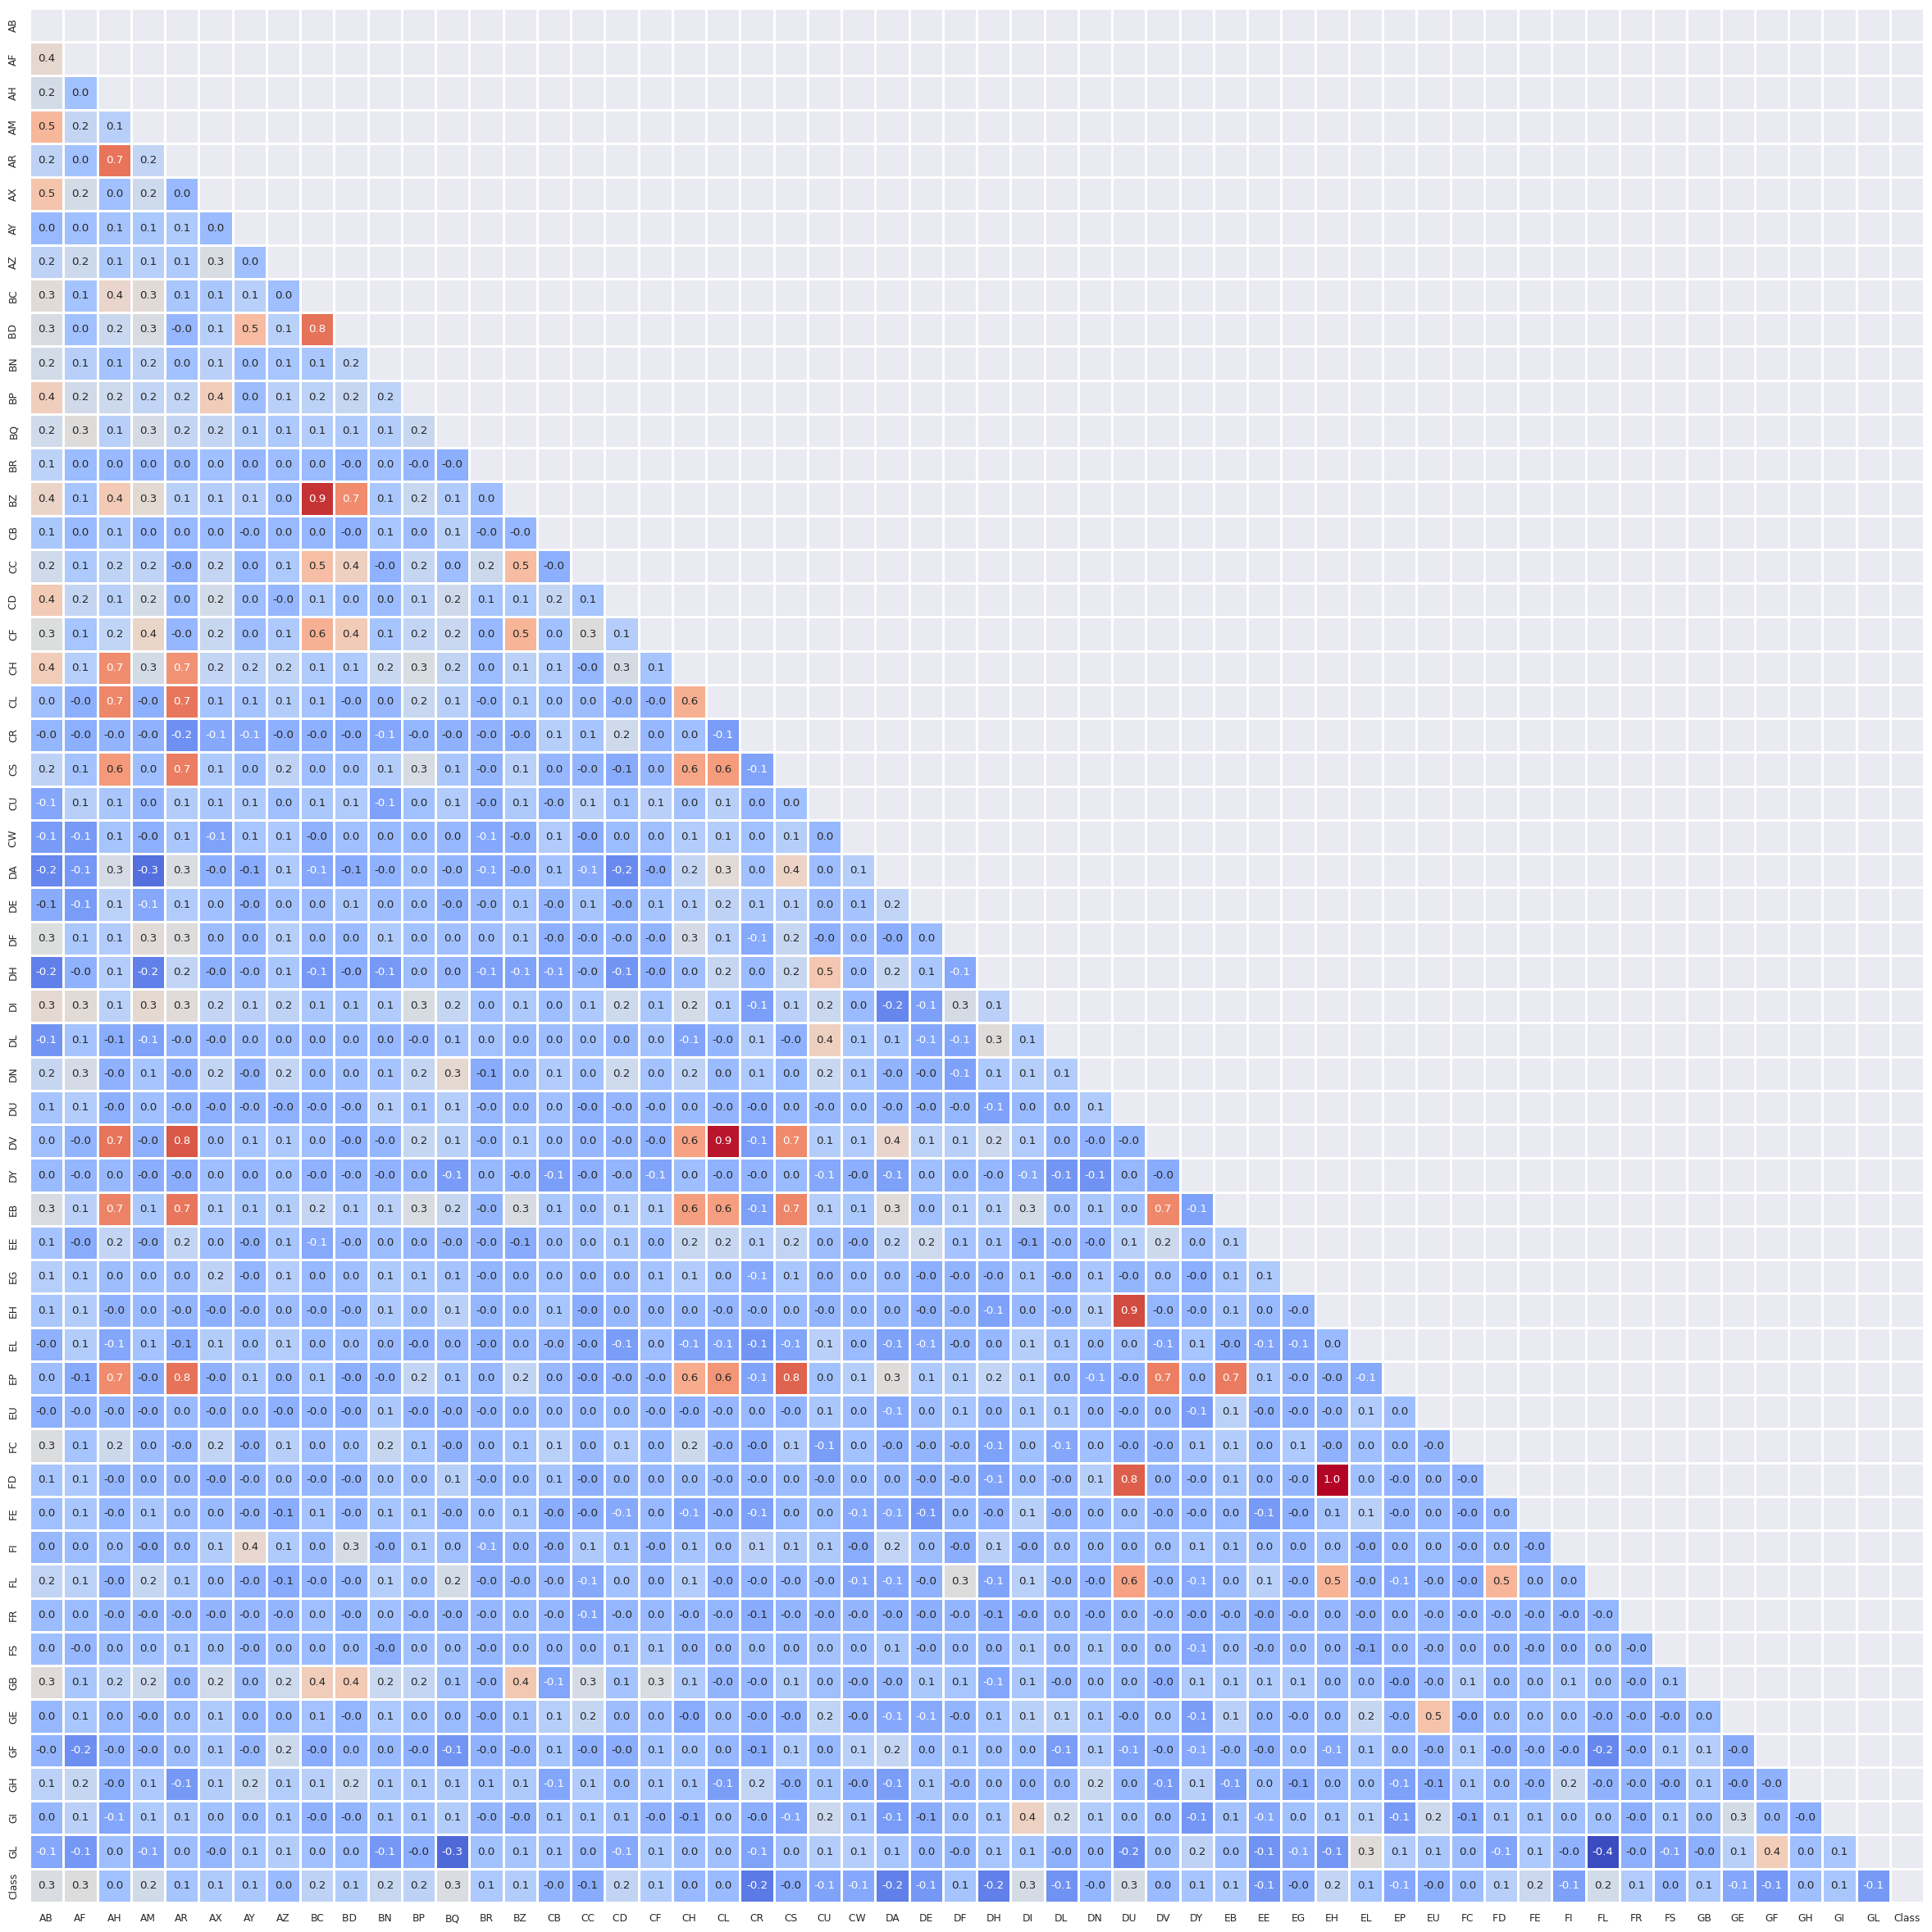

In [12]:
sns.set(font_scale=0.8)
correlation_train = train_df.corr()
mask = np.triu(correlation_train.corr())
plt.figure(figsize=(30, 30))
sns.heatmap(correlation_train,
            annot=True,
            fmt='.1f',
            cmap='coolwarm',
            square=True,
            mask=mask,
            linewidths=1,
            cbar=False);

Mutual information is another measure, which also capable to measure more diverse relationships and good at categorical and discrete variables.

In [13]:
y= train_df['Class']

In [14]:

# determine the mutual information for numerical features
#You need to fillna to get results from mutual_info_regression function
mutual_df = train_df[continuous_features]

mutual_info = mutual_info_classif(mutual_df.fillna(0), y, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["MI_score"] ).style.background_gradient("cool")


,MI_score
DU,0.109387
FL,0.082239
GL,0.066382
BQ,0.058249
AF,0.056244
DI,0.055311
BC,0.055097
FD,0.049730
CC,0.049244
DA,0.048167


In [15]:
mutual_df_categorical = train_df[categorical_features]
#categorical features must be encoded to get mutual information
for colname in mutual_df_categorical:
    mutual_df_categorical[colname], _ = mutual_df_categorical[colname].factorize()
mutual_info = mutual_info_classif(mutual_df_categorical, y, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df_categorical.columns
pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["Categorical_Feature_MI"] ).style.background_gradient("cool")

,Categorical_Feature_MI
EJ,0.017423


<a id = "4"></a><br>
# Feature Engineering

Later...

<a id = "7"></a><br>
## A custom pipeline for Feature Engineering (Not Used)

In [16]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, drop_attributes=True):
        
        self.drop_attributes = drop_attributes
        
    def fit(self, X, y=None):
        
        return self
    
    def transform(self, X):
        
        if self.drop_attributes:
            X_copy = X.copy()
            
            
            X_copy= X_copy.drop(['EG','CH','DL','GB','CB','DY','CU','EL','BZ','DN','AZ','EP','DV'], axis=1)
           
  
            return X_copy
        else:
            return X_copy

In [17]:
Dropper = FeatureDropper(drop_attributes = True)

<a id = "8"></a><br>
#  Scikit-learn pipeline with AutoML

In [18]:
y = pipe_data['Class']
pipe_data = pipe_data.drop(['Class'], axis=1)
pipe_data.head()

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,4126.58731,...,3.583450,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343
1,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,5496.92824,...,10.358927,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000
2,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,5135.78024,...,11.626917,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941
3,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,4169.67738,...,14.852022,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829
4,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,5728.73412,...,13.666727,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614


In [19]:
#flaml
from flaml import AutoML

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [21]:
numerical_transformer = Pipeline(steps=[
    
    ('imputer', SimpleImputer(strategy='constant', fill_value = 0))
])
# Preprocessing for categorical data
nominal_transformer = Pipeline(steps=[
    
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [22]:
tree_preprocessor = ColumnTransformer(remainder=numerical_transformer,
    transformers=[

        
        ('nominal_transformer', nominal_transformer, categorical_features),        
            
    ])


set_config(display="diagram")
tree_preprocessor

ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                             SimpleImputer(fill_value=0,
                                                           strategy='constant'))]),
                  transformers=[('nominal_transformer',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['EJ'])])

In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline

In [24]:
sm = SMOTE(random_state=42)

In [25]:
automl = AutoML()

automl_pipeline = imbpipeline([
    
    ('Dropper', Dropper),
    ('tree_preprocessor', tree_preprocessor),
    ('smote', sm),
    ("automl", automl)
])
automl_pipeline

Pipeline(steps=[('Dropper', FeatureDropper()),
                ('tree_preprocessor',
                 ColumnTransformer(remainder=Pipeline(steps=[('imputer',
                                                              SimpleImputer(fill_value=0,
                                                                            strategy='constant'))]),
                                   transformers=[('nominal_transformer',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EJ'])])),
                ('smote', SMOTE(random_state=42)),
                ('automl',
                 AutoML(append_log=F...
                        keep_search_state=False, learner_selector='sample',
                        log_file_name='', log_training_metric=False,
                        log_type='better', max_iter=None, mem_thres=4294967296,
                        metric='auto', metric_constraints=[],
                        min_sample_size=10000, mlflow_logging=True,
                        model_history=False, n_concurrent_trials=1, n_jobs=-1,
                        n_splits=5, pred_time_limit=inf,
                        preserve_checkpoint=True, retrain_full=True, ...))])

In [26]:
# Specify automl goal and constraint
automl_settings = {
    "time_budget": 3600,  # total running time in seconds
    "task": 'classification',  # task type
    "seed": 7654321,  # random seed
    "metric" : 'log_loss',
    "eval_method" : 'cv',
    "n_splits" : 10,
    "ensemble": True
    
}

pipeline_settings = {f"automl__{key}": value for key, value in automl_settings.items()}

In [27]:
automl_pipeline = automl_pipeline.fit(pipe_data, y, **pipeline_settings)

[flaml.automl.logger: 06-04 21:01:45] {1693} INFO - task = classification
[flaml.automl.logger: 06-04 21:01:45] {1700} INFO - Data split method: stratified
[flaml.automl.logger: 06-04 21:01:45] {1703} INFO - Evaluation method: cv
[flaml.automl.logger: 06-04 21:01:45] {1801} INFO - Minimizing error metric: log_loss
[flaml.automl.logger: 06-04 21:01:45] {1911} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'catboost', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'lrl1']
[flaml.automl.logger: 06-04 21:01:45] {2221} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 06-04 21:01:45] {2347} INFO - Estimated sufficient time budget=2005s. Estimated necessary time budget=49s.
[flaml.automl.logger: 06-04 21:01:45] {2394} INFO -  at 0.4s,	estimator lgbm's best error=0.5381,	best estimator lgbm's best error=0.5381
[flaml.automl.logger: 06-04 21:01:45] {2221} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-04 21:01:45] {2394} INFO -  at 0.6s,	estimator lgbm's b

In [28]:
preds_test = automl_pipeline.predict_proba(pipe_test)

### <a id = "13"></a><br>
# Submission

In [29]:
sub = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv')
sub[["class_0","class_1"]] = preds_test
sub.to_csv("submission.csv", index=False)
sub

,Id,class_0,class_1
0,00eed32682bb,0.49995,0.50005
1,010ebe33f668,0.49995,0.50005
2,02fa521e1838,0.49995,0.50005
3,040e15f562a2,0.49995,0.50005
4,046e85c7cc7f,0.49995,0.50005
